In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, List
from numpy.typing import NDArray

In [3]:
Vector = NDArray[np.float64]

In [4]:
def load_data(filename: str) -> Tuple[Vector, Vector]:
    df = pd.read_csv(filename, header=None)
    df = df.sort_values(by=0)
    return df[0].values, df[1].values

In [5]:
def true_f(t: Vector) -> Vector:
    return 2.14 * (t + 1.4) * (t + 5.3) * (t - 0.44)

In [6]:
t_data, y_data = load_data('punkty.csv')
t_plot = np.linspace(t_data.min(), t_data.max(), 500)

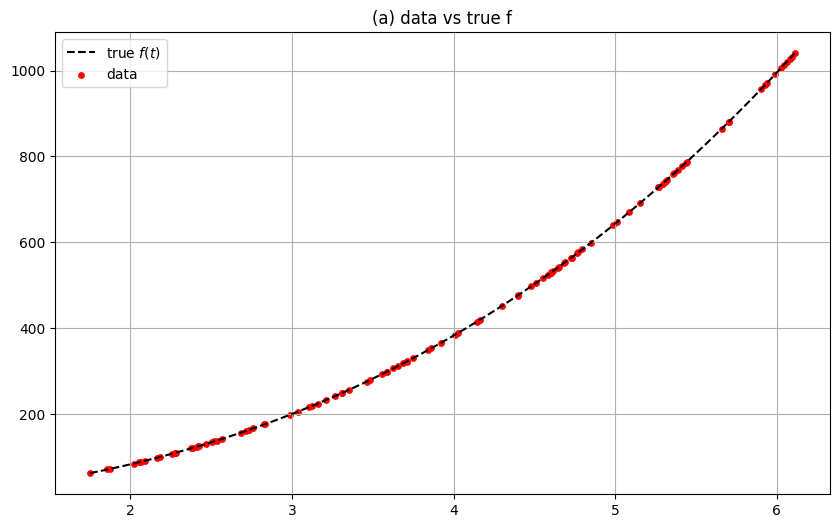

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(t_plot, true_f(t_plot), 'k--', label='true $f(t)$')
plt.scatter(t_data, y_data, c='r', s=15, label='data')
plt.title('(a) data vs true f')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\aszki\AppData\Local\Temp\ipykernel_134964\89328011.py:3: RankWarning: Polyfit may be poorly conditioned
  coeffs_interp = np.polyfit(t_data, y_data, 105)


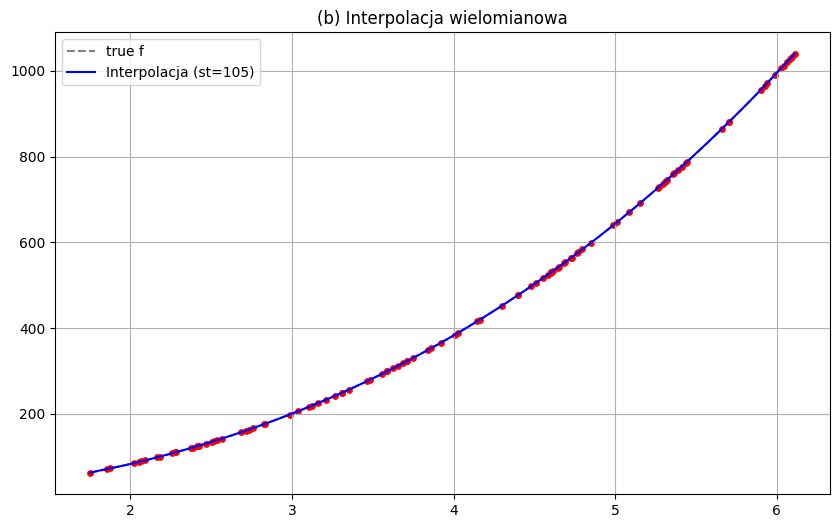

In [8]:
deg_interp = len(t_data) - 1

coeffs_interp = np.polyfit(t_data, y_data, 105)
p_interp = np.poly1d(coeffs_interp)

plt.figure(figsize=(10, 6))
plt.plot(t_plot, true_f(t_plot), 'k--', alpha=0.5, label='true f')
plt.plot(t_plot, p_interp(t_plot), 'b-', label=f'Interpolacja (st={deg_interp})')
plt.scatter(t_data, y_data, c='r', s=15)
plt.ylim(y_data.min() - 50, y_data.max() + 50)
plt.title('(b) Interpolacja wielomianowa')
plt.legend()
plt.grid(True)
plt.show()

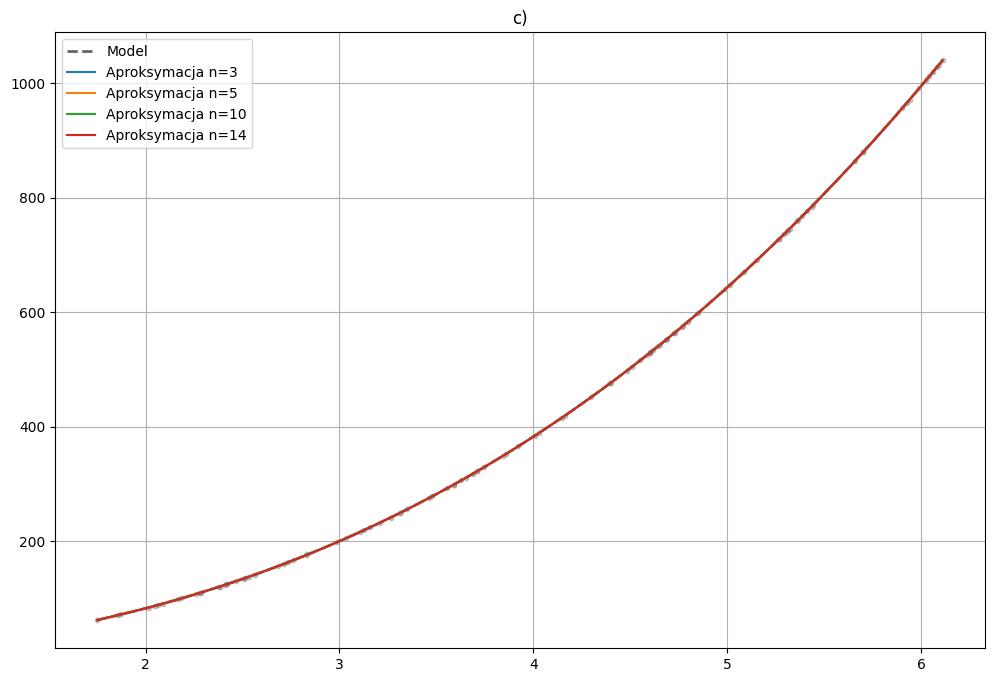

In [9]:
def get_recurrence_coeffs(x: Vector, n: int) -> Tuple[Vector, Vector, List[Vector]]:
    """oblicza wspolczynniki c, d rekurencji oraz wartosci wielomianow w wezlach x."""
    m = len(x)
    c = np.zeros(n + 1)
    d = np.zeros(n + 1)
    P = [np.zeros(m) for _ in range(n + 1)]

    # P_0
    P[0] = np.ones(m)
    sq_norm_prev = np.dot(P[0], P[0]) # <P0, P0>

    # P_1
    c[1] = np.dot(x * P[0], P[0]) / sq_norm_prev
    P[1] = x - c[1]
    sq_norm_curr = np.dot(P[1], P[1])

    # P_k dla k >= 2
    for k in range(2, n + 1):
        d[k] = sq_norm_curr / sq_norm_prev
        sq_norm_prev = sq_norm_curr

        c[k] = np.dot(x * P[k-1], P[k-1]) / sq_norm_curr

        P[k] = (x - c[k]) * P[k-1] - d[k] * P[k-2]
        sq_norm_curr = np.dot(P[k], P[k])

    return c, d, P

def eval_poly_ortho(t_eval: Vector, alphas: Vector, c: Vector, d: Vector) -> Vector:
    """oblicza wartosc wielomianu aproksymuajcego w punktach t_eval."""
    n = len(alphas) - 1
    m = len(t_eval)

    # Wartosci P_k w nowych punktach (t_eval)
    P_prev = np.ones(m) # P_0
    val = alphas[0] * P_prev

    if n >= 1:
        P_curr = t_eval - c[1] # P_1
        val += alphas[1] * P_curr

        for k in range(2, n + 1):
            P_next = (t_eval - c[k]) * P_curr - d[k] * P_prev
            val += alphas[k] * P_next
            P_prev, P_curr = P_curr, P_next

    return val


max_deg = 15
c_coeffs, d_coeffs, P_basis_vals = get_recurrence_coeffs(t_data, max_deg)

# obliczenie wspolczynników Fouriera a_k = <y, P_k> / <P_k, P_k>

all_alphas = []
for k in range(max_deg + 1):
    numerator = np.dot(y_data, P_basis_vals[k])
    denominator = np.dot(P_basis_vals[k], P_basis_vals[k])
    all_alphas.append(numerator / denominator)
all_alphas = np.array(all_alphas)

plt.figure(figsize=(12, 8))
plt.plot(t_plot, true_f(t_plot), 'k--', lw=2, alpha=0.6, label='Model')
plt.scatter(t_data, y_data, c='gray', s=10, alpha=0.4)

# Rysowanie wybranych stopni z przedziału 2 < n < 15
degrees_to_plot = [3, 5, 10, 14]
for n in degrees_to_plot:
    y_approx = eval_poly_ortho(t_plot, all_alphas[:n+1], c_coeffs, d_coeffs)
    plt.plot(t_plot, y_approx, label=f'Aproksymacja n={n}')

plt.title('c)')
plt.legend()
plt.grid(True)
plt.show()